In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

print("Library siap!")

Library siap!


In [2]:
# Kategori yang akan diklasifikasi model
CATEGORIES = {
    "Makanan & Minuman": [
        "Makan siang warteg", "Beli kopi Kenangan", "Indomaret snack",
        "Gofood ayam geprek", "Grab food mie ayam", "Beli boba",
        "Makan malam padang", "Jajan pasar", "Beli air mineral galon",
        "Sarapan nasi uduk", "Pizza Hut", "KFC", "McDonald",
        "Beli telur & sayur", "Bakso solo", "Es teh manis"
    ],
    "Transportasi": [
        "Grab ke kantor", "Gojek pulang kerja", "Bensin motor",
        "Parkir mall", "Tiket KRL", "Tiket busway", "Ojek online kampus",
        "Bensin mobil", "Tol Jakarta Bekasi", "Tiket kereta Bandung"
    ],
    "Hiburan": [
        "Nonton bioskop CGV", "Netflix bulanan", "Spotify premium",
        "Game top up Mobile Legends", "Karaoke happy hour",
        "Tiket konser", "Steam game", "YouTube Premium",
        "Top up Free Fire", "Tiket wahana Dufan"
    ],
    "Kesehatan": [
        "Beli obat apotek", "Vitamin C Redoxon", "Konsultasi dokter umum",
        "Beli masker", "Iuran BPJS", "Beli hand sanitizer",
        "Klinik gigi", "Beli paracetamol", "Suplemen olahraga"
    ],
    "Belanja": [
        "Beli baju Uniqlo", "Shopee belanja bulanan", "Tokopedia elektronik",
        "Beli sepatu", "Alfamart kebutuhan rumah", "Beli charger HP",
        "Deterjen & sabun", "Skincare Wardah", "Beli tas ransel"
    ],
    "Pendidikan": [
        "Kursus online Udemy", "Beli buku programming", "Langganan Coursera",
        "Beli alat tulis", "Fotokopi materi kuliah", "Beli jurnal",
        "Kursus bahasa Inggris", "Beli flashcard"
    ],
    "Tagihan": [
        "Bayar listrik PLN", "Tagihan internet Indihome", "Beli pulsa",
        "Bayar air PDAM", "Tagihan kartu kredit", "Cicilan HP",
        "Top up GoPay", "Top up OVO", "Bayar kos bulanan"
    ],
}

print(f"Total kategori: {len(CATEGORIES)}")
for cat, items in CATEGORIES.items():
    print(f"  {cat}: {len(items)} jenis transaksi")

Total kategori: 7
  Makanan & Minuman: 16 jenis transaksi
  Transportasi: 10 jenis transaksi
  Hiburan: 10 jenis transaksi
  Kesehatan: 9 jenis transaksi
  Belanja: 9 jenis transaksi
  Pendidikan: 8 jenis transaksi
  Tagihan: 9 jenis transaksi


In [3]:
def generate_dataset(n_samples=1000):
    rows = []

    # Range nominal per kategori (min, max) dalam Rupiah
    nominal_range = {
        "Makanan & Minuman": (8_000, 150_000),
        "Transportasi":      (3_000, 200_000),
        "Hiburan":           (15_000, 500_000),
        "Kesehatan":         (10_000, 300_000),
        "Belanja":           (20_000, 800_000),
        "Pendidikan":        (10_000, 500_000),
        "Tagihan":           (20_000, 1_000_000),
    }

    categories = list(CATEGORIES.keys())
    start_date = datetime(2024, 1, 1)

    for _ in range(n_samples):
        # Pilih kategori secara acak
        category = random.choice(categories)

        # Pilih nama transaksi dari kategori tersebut
        nama = random.choice(CATEGORIES[category])

        # Generate nominal yang realistis
        min_val, max_val = nominal_range[category]
        # Nominal selalu kelipatan 500
        nominal = random.randint(min_val // 500, max_val // 500) * 500

        # Generate tanggal acak dalam setahun
        random_days = random.randint(0, 365)
        tanggal = start_date + timedelta(days=random_days)

        # Tambah fitur waktu
        hari_dalam_seminggu = tanggal.weekday()  # 0=Senin, 6=Minggu
        bulan = tanggal.month
        adalah_weekend = 1 if hari_dalam_seminggu >= 5 else 0

        rows.append({
            "nama_transaksi": nama,
            "nominal": nominal,
            "tanggal": tanggal.strftime("%Y-%m-%d"),
            "bulan": bulan,
            "hari_dalam_seminggu": hari_dalam_seminggu,
            "adalah_weekend": adalah_weekend,
            "kategori": category,
        })

    return pd.DataFrame(rows)

# Generate 1000 data
df = generate_dataset(1000)
print(f"Dataset berhasil dibuat: {df.shape[0]} baris, {df.shape[1]} kolom")
print()
df.head(10)

Dataset berhasil dibuat: 1000 baris, 7 kolom



,nama_transaksi,nominal,tanggal,bulan,hari_dalam_seminggu,adalah_weekend,kategori
0,Bayar air PDAM,496500,2024-09-10,9,1,0,Tagihan
1,Tiket kereta Bandung,160500,2024-09-28,9,5,1,Transportasi
2,Beli paracetamol,100000,2024-10-12,10,5,1,Kesehatan
3,Konsultasi dokter umum,293500,2024-06-19,6,2,0,Kesehatan
4,Kursus bahasa Inggris,241500,2024-09-01,9,6,1,Pendidikan
5,Vitamin C Redoxon,60500,2024-04-05,4,4,0,Kesehatan
6,Beli telur & sayur,8000,2024-02-15,2,3,0,Makanan & Minuman
7,Beli flashcard,220000,2024-10-17,10,3,0,Pendidikan
8,Beli kopi Kenangan,83000,2024-08-31,8,5,1,Makanan & Minuman
9,Beli air mineral galon,101000,2024-06-24,6,0,0,Makanan & Minuman


In [4]:
# Cek distribusi kategori — pastikan tidak terlalu timpang
print("Distribusi kategori:")
print(df["kategori"].value_counts())
print()

# Simpan ke CSV
df.to_csv("dataset_transaksi.csv", index=False)
print("Dataset tersimpan sebagai: dataset_transaksi.csv")

# Download otomatis ke laptop kamu
from google.colab import files
files.download("dataset_transaksi.csv")

Distribusi kategori:
kategori
Tagihan              158
Kesehatan            151
Transportasi         150
Hiburan              147
Belanja              139
Pendidikan           135
Makanan & Minuman    120
Name: count, dtype: int64

Dataset tersimpan sebagai: dataset_transaksi.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset_transaksi.csv")
print(df.shape)
print()
print(df.dtypes)
print()
print(df.head(3))

(1000, 7)

nama_transaksi         object
nominal                 int64
tanggal                object
bulan                   int64
hari_dalam_seminggu     int64
adalah_weekend          int64
kategori               object
dtype: object

         nama_transaksi  nominal     tanggal  bulan  hari_dalam_seminggu  \
0        Bayar air PDAM   496500  2024-09-10      9                    1   
1  Tiket kereta Bandung   160500  2024-09-28      9                    5   
2      Beli paracetamol   100000  2024-10-12     10                    5   

   adalah_weekend      kategori  
0               0       Tagihan  
1               1  Transportasi  
2               1     Kesehatan  


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["kategori"])

print("Mapping kategori → angka:")
for i, cat in enumerate(le.classes_):
    print(f"  {i} = {cat}")

Mapping kategori → angka:
  0 = Belanja
  1 = Hiburan
  2 = Kesehatan
  3 = Makanan & Minuman
  4 = Pendidikan
  5 = Tagihan
  6 = Transportasi


In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenizer mengubah setiap kata jadi angka
tokenizer = Tokenizer(num_words=500, oov_token="<OOV>")
tokenizer.fit_on_texts(df["nama_transaksi"])

# Ubah teks jadi sequence angka
sequences = tokenizer.texts_to_sequences(df["nama_transaksi"])

# Samakan panjang semua sequence (padding)
MAX_LEN = 10
X_text = pad_sequences(sequences, maxlen=MAX_LEN, padding="post")

print(f"Contoh teks asli  : '{df['nama_transaksi'][0]}'")
print(f"Setelah tokenize  : {sequences[0]}")
print(f"Setelah padding   : {X_text[0]}")
print(f"Shape X_text      : {X_text.shape}")

Contoh teks asli  : 'Bayar air PDAM'
Setelah tokenize  : [4, 8, 16]
Setelah padding   : [ 4  8 16  0  0  0  0  0  0  0]
Shape X_text      : (1000, 10)


In [8]:
# Fitur numerik: nominal, bulan, hari, weekend
X_num = df[["nominal", "bulan", "hari_dalam_seminggu", "adalah_weekend"]].values

# Normalisasi nominal supaya tidak dominan (skala 0-1)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_num = scaler.fit_transform(X_num)

# Label
y = df["label"].values

print(f"Shape X_text : {X_text.shape}")
print(f"Shape X_num  : {X_num.shape}")
print(f"Shape y      : {y.shape}")
print(f"Contoh y     : {y[:5]}")

Shape X_text : (1000, 10)
Shape X_num  : (1000, 4)
Shape y      : (1000,)
Contoh y     : [5 6 2 2 4]


In [9]:
from sklearn.model_selection import train_test_split

# Split X_text
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# Split X_num dengan index yang sama
X_num_train, X_num_test = train_test_split(
    X_num, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_text_train.shape[0]} data")
print(f"Test set     : {X_text_test.shape[0]} data")
print()
print("Distribusi label di training set:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c}")

Training set : 800 data
Test set     : 200 data

Distribusi label di training set:
  Belanja: 111
  Hiburan: 118
  Kesehatan: 121
  Makanan & Minuman: 96
  Pendidikan: 108
  Tagihan: 126
  Transportasi: 120


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# ── Input 1: Teks nama transaksi ──────────────────────────────
input_text = tf.keras.Input(shape=(10,), name="input_text")
x = layers.Embedding(input_dim=500, output_dim=32, name="embedding")(input_text)
x = layers.GlobalAveragePooling1D(name="pooling")(x)
x = layers.Dense(64, activation="relu", name="text_dense")(x)

# ── Input 2: Fitur numerik ────────────────────────────────────
input_num = tf.keras.Input(shape=(4,), name="input_num")
y_num = layers.Dense(32, activation="relu", name="num_dense")(input_num)

# ── Gabungkan keduanya ────────────────────────────────────────
combined = layers.Concatenate(name="combine")([x, y_num])
combined = layers.Dense(64, activation="relu", name="combined_dense")(combined)
combined = layers.Dropout(0.3, name="dropout")(combined)

# ── Output: 7 kategori ────────────────────────────────────────
output = layers.Dense(7, activation="softmax", name="output")(combined)

model = Model(inputs=[input_text, input_num], outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_text          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 10, 32)    │     16,000 │ input_text[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling             │ (None, 32)        │          0 │ embedding[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_num           │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_dense (Dense)  │ (None, 64)        │      2,112 │ pooling[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_dense (Dense)   │ (None, 32)        │        160 │ input_num[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combine             │ (None, 96)        │          0 │ text_dense[0][0], │
│ (Concatenate)       │                   │            │ num_dense[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_dense      │ (None, 64)        │      6,208 │ combine[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ combined_dense[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 7)         │        455 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,935 (97.40 KB)

 Trainable params: 24,935 (97.40 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Setup
EPOCHS     = 20
BATCH_SIZE = 32
NUM_CLASSES = 7

loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Konversi ke tensor
X_text_train_t = tf.constant(X_text_train)
X_num_train_t  = tf.constant(X_num_train,  dtype=tf.float32)
y_train_t      = tf.constant(y_train)

X_text_test_t  = tf.constant(X_text_test)
X_num_test_t   = tf.constant(X_num_test,   dtype=tf.float32)
y_test_t       = tf.constant(y_test)

# Dataset object untuk batching
train_dataset = tf.data.Dataset.from_tensor_slices(
    ((X_text_train_t, X_num_train_t), y_train_t)
).shuffle(800).batch(BATCH_SIZE)

# Tracking history untuk grafik nanti
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Mulai training...\n")

for epoch in range(EPOCHS):
    # ── Training ──────────────────────────────────────────────
    train_loss_sum = 0
    train_correct  = 0
    n_batches      = 0

    for (batch_text, batch_num), batch_y in train_dataset:

        with tf.GradientTape() as tape:
            predictions = model([batch_text, batch_num], training=True)
            loss = loss_fn(batch_y, predictions)

        # Hitung gradients lalu update bobot model
        gradients = tape.gradient(loss, model.trainable_variables)

        # Gradient clipping — mencegah gradients meledak
        gradients, _ = tf.clip_by_global_norm(gradients, clip_norm=1.0)

        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        train_loss_sum += loss.numpy()
        train_correct  += tf.reduce_sum(
            tf.cast(tf.argmax(predictions, axis=1) == tf.cast(batch_y, tf.int64), tf.int32)
        ).numpy()
        n_batches += 1

    train_loss = train_loss_sum / n_batches
    train_acc  = train_correct / len(y_train)

    # ── Validasi ──────────────────────────────────────────────
    val_preds = model([X_text_test_t, X_num_test_t], training=False)
    val_loss  = loss_fn(y_test_t, val_preds).numpy()
    val_acc   = tf.reduce_mean(
        tf.cast(tf.argmax(val_preds, axis=1) == tf.cast(y_test_t, tf.int64), tf.float32)
    ).numpy()

    # Simpan history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} — "
          f"loss: {train_loss:.4f} — acc: {train_acc:.4f} — "
          f"val_loss: {val_loss:.4f} — val_acc: {val_acc:.4f}")

Mulai training...

Epoch  1/20 — loss: 1.9357 — acc: 0.1825 — val_loss: 1.9260 — val_acc: 0.1550
Epoch  2/20 — loss: 1.9042 — acc: 0.2238 — val_loss: 1.8861 — val_acc: 0.2850
Epoch  3/20 — loss: 1.8533 — acc: 0.3488 — val_loss: 1.8021 — val_acc: 0.4800
Epoch  4/20 — loss: 1.7172 — acc: 0.5012 — val_loss: 1.5889 — val_acc: 0.6750
Epoch  5/20 — loss: 1.4262 — acc: 0.6650 — val_loss: 1.2034 — val_acc: 0.7750
Epoch  6/20 — loss: 1.0477 — acc: 0.7700 — val_loss: 0.8045 — val_acc: 0.9000
Epoch  7/20 — loss: 0.6878 — acc: 0.8550 — val_loss: 0.5031 — val_acc: 0.9850
Epoch  8/20 — loss: 0.4528 — acc: 0.9150 — val_loss: 0.3246 — val_acc: 0.9850
Epoch  9/20 — loss: 0.3253 — acc: 0.9487 — val_loss: 0.2289 — val_acc: 0.9900
Epoch 10/20 — loss: 0.2386 — acc: 0.9688 — val_loss: 0.1580 — val_acc: 1.0000
Epoch 11/20 — loss: 0.1746 — acc: 0.9838 — val_loss: 0.1072 — val_acc: 1.0000
Epoch 12/20 — loss: 0.1279 — acc: 0.9875 — val_loss: 0.0774 — val_acc: 0.9950
Epoch 13/20 — loss: 0.1095 — acc: 0.9838 — va

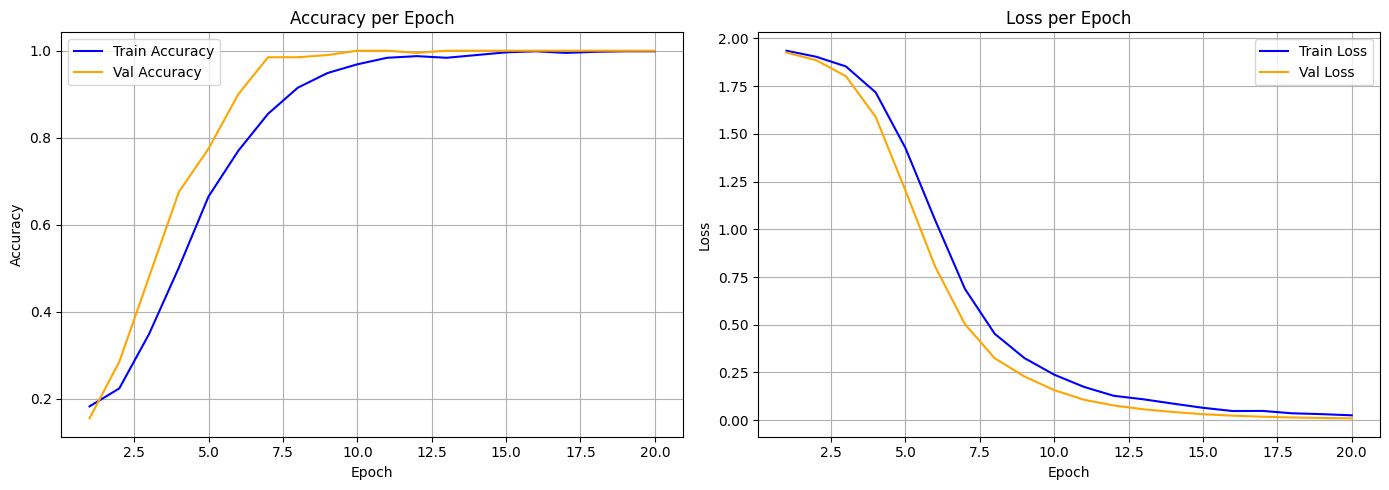

Grafik tersimpan!


In [12]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

# Accuracy
ax1.plot(epochs_range, history["train_acc"], label="Train Accuracy", color="blue")
ax1.plot(epochs_range, history["val_acc"],   label="Val Accuracy",   color="orange")
ax1.set_title("Accuracy per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(epochs_range, history["train_loss"], label="Train Loss", color="blue")
ax2.plot(epochs_range, history["val_loss"],   label="Val Loss",   color="orange")
ax2.set_title("Loss per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()
print("Grafik tersimpan!")

=== Classification Report ===

                   precision    recall  f1-score   support

          Belanja       1.00      1.00      1.00        28
          Hiburan       1.00      1.00      1.00        29
        Kesehatan       1.00      1.00      1.00        30
Makanan & Minuman       1.00      1.00      1.00        24
       Pendidikan       1.00      1.00      1.00        27
          Tagihan       1.00      1.00      1.00        32
     Transportasi       1.00      1.00      1.00        30

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



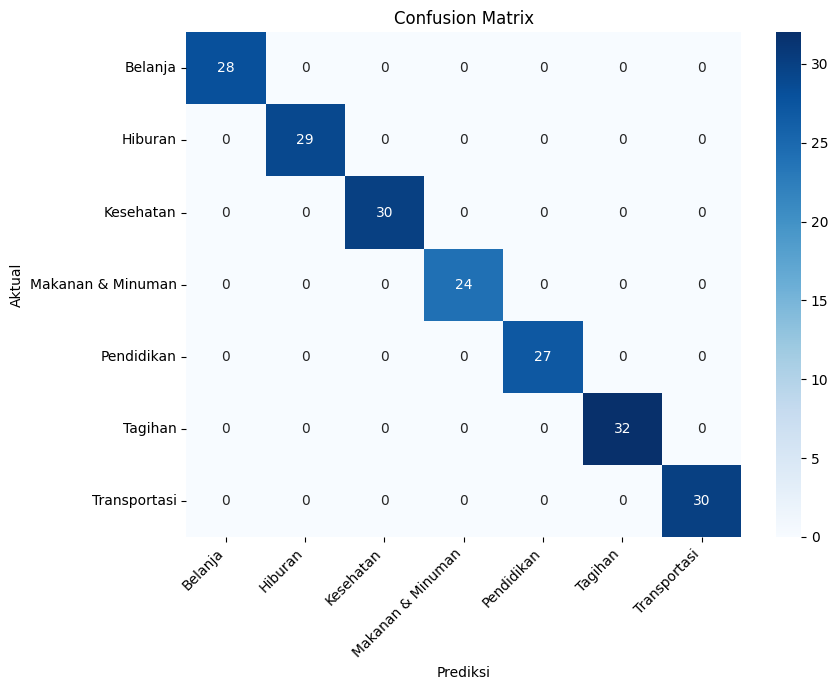

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Prediksi test set
val_preds_np = tf.argmax(
    model([X_text_test_t, X_num_test_t], training=False), axis=1
).numpy()

# Classification report
print("=== Classification Report ===\n")
print(classification_report(y_test, val_preds_np, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, val_preds_np)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix")
plt.ylabel("Aktual")
plt.xlabel("Prediksi")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [14]:
import pickle
import os

# Buat folder untuk semua artefak model
os.makedirs("finsight_model", exist_ok=True)

# 1. Simpan model TensorFlow
model.save("finsight_model/classifier.keras")
print("Model tersimpan!")

# 2. Simpan tokenizer (dibutuhkan untuk encode input baru)
with open("finsight_model/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
print("Tokenizer tersimpan!")

# 3. Simpan scaler (dibutuhkan untuk normalisasi nominal)
with open("finsight_model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Scaler tersimpan!")

# 4. Simpan label encoder (untuk decode angka → nama kategori)
with open("finsight_model/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("Label encoder tersimpan!")

# Cek isi folder
print("\nIsi folder finsight_model/:")
for f in os.listdir("finsight_model"):
    size = os.path.getsize(f"finsight_model/{f}")
    print(f"  {f} ({size:,} bytes)")

Model tersimpan!
Tokenizer tersimpan!
Scaler tersimpan!
Label encoder tersimpan!

Isi folder finsight_model/:
  label_encoder.pkl (333 bytes)
  scaler.pkl (642 bytes)
  tokenizer.pkl (4,230 bytes)
  classifier.keras (137,308 bytes)


In [15]:
def predict_kategori(nama_transaksi, nominal, tanggal_str):
    """
    Fungsi prediksi — ini yang nantinya akan dipanggil FastAPI.

    Input:
      - nama_transaksi : str  → misal "Grab ke kantor"
      - nominal        : int  → misal 25000
      - tanggal_str    : str  → misal "2024-03-15"

    Output:
      - kategori       : str  → misal "Transportasi"
      - confidence     : float → misal 0.97
    """
    from datetime import datetime

    # Parse tanggal
    tanggal = datetime.strptime(tanggal_str, "%Y-%m-%d")
    bulan            = tanggal.month
    hari_dalam_seminggu = tanggal.weekday()
    adalah_weekend   = 1 if hari_dalam_seminggu >= 5 else 0

    # Encode teks
    seq = tokenizer.texts_to_sequences([nama_transaksi])
    seq_padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post")

    # Normalisasi numerik
    num_raw = np.array([[nominal, bulan, hari_dalam_seminggu, adalah_weekend]])
    num_scaled = scaler.transform(num_raw)

    # Prediksi
    pred = model([
        tf.constant(seq_padded),
        tf.constant(num_scaled, dtype=tf.float32)
    ], training=False)

    pred_class = tf.argmax(pred, axis=1).numpy()[0]
    confidence = float(tf.reduce_max(pred).numpy())
    kategori   = le.inverse_transform([pred_class])[0]

    return kategori, confidence


# ── Test dengan beberapa contoh ──────────────────────────────
test_cases = [
    ("Grab ke kantor",        25_000, "2024-03-15"),
    ("Beli obat apotek",      45_000, "2024-03-16"),
    ("Netflix bulanan",       54_000, "2024-03-17"),
    ("Bayar listrik PLN",    150_000, "2024-03-01"),
    ("Makan siang warteg",    15_000, "2024-03-18"),
    ("Beli baju Uniqlo",     299_000, "2024-03-20"),
    ("Kursus online Udemy",  129_000, "2024-03-21"),
]

print("=== Test Prediksi ===\n")
print(f"{'Nama Transaksi':<30} {'Nominal':>10}  {'Prediksi':<22} {'Confidence':>10}")
print("-" * 80)
for nama, nominal, tgl in test_cases:
    kat, conf = predict_kategori(nama, nominal, tgl)
    print(f"{nama:<30} {nominal:>10,}  {kat:<22} {conf:>9.1%}")

=== Test Prediksi ===

Nama Transaksi                    Nominal  Prediksi               Confidence
--------------------------------------------------------------------------------
Grab ke kantor                     25,000  Transportasi               99.7%
Beli obat apotek                   45,000  Kesehatan                  99.2%
Netflix bulanan                    54,000  Hiburan                    99.2%
Bayar listrik PLN                 150,000  Tagihan                   100.0%
Makan siang warteg                 15,000  Makanan & Minuman          98.9%
Beli baju Uniqlo                  299,000  Belanja                    99.3%
Kursus online Udemy               129,000  Pendidikan                 99.8%


In [16]:
import shutil

# Zip seluruh folder
shutil.make_archive("finsight_model", "zip", "finsight_model")
print("File ter-zip!")

# Download ke laptop
from google.colab import files
files.download("finsight_model.zip")
print("Download dimulai!")

File ter-zip!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download dimulai!
